In [1]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2

# 6.06 — Effective sensitivity scalars (shared basis)

Three **single scalars per session/subject**, all on the shared 4-state basis so they are
directly comparable across groups (no per-group "which state is lapse" threshold needed):

| scalar | definition | meaning |
|---|---|---|
| **Effective stimulus sensitivity** | $\sum_s \text{occ}_s \, w^{\text{stim}}_s$ | how strongly evidence drives choice |
| **Effective prior sensitivity** | $\sum_s \text{occ}_s\,\sigma(w^{\text{bias}}_s + w^{\text{color}}_s) - \sum_s \text{occ}_s\,\sigma(w^{\text{bias}}_s)$ | prior-induced shift in $P(\text{right})$ at zero coherence |
| **Total lapse occupancy** | $\text{occ}_{\text{lapse}}$ | time spent in the flat (stimulus-insensitive) state |

Weights $w_s$ come from the **shared pooled model** (common basis); occupancy $\text{occ}_s$ is
per session under that same model. Effective **prior** sensitivity is the **probability-units
prior-bias index** (identical to 6.03 / 6.10) — the prior's effect at the decision boundary,
which is the quantity that validated against the DDM drift offset (6.10, r ≈ 0.22, p ≈ 0.03) —
rather than a raw logit-weight sum. Each scalar still folds weight × occupancy into one
comparable number. Tests: within-subject Wilcoxon OFF vs ON (Tremor, Brady separately),
Mann-Whitney HC vs PD-OFF on all three, and Spearman vs clinical severity (UPDRS) across PD-OFF
subjects.

In [2]:
import json
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon, mannwhitneyu, spearmanr

from imports import *
from config import dir_config
from src.shared_glm_hmm.grouping import session_metadata

In [3]:
processed_dir = Path(dir_config.data.processed)
shared_dir = processed_dir / "shared_glm_hmm"
# Track the model finalized in 6.00 (selected_model.json); fall back to XY__tgt if absent.
_sel = shared_dir / "selected_model.json"
SELECTED = json.loads(_sel.read_text())["config"] if _sel.exists() else "XY__tgt"
CONFIG = SELECTED

bundle = pickle.load(open(shared_dir / CONFIG / "all_subjects_final.pkl", "rb"))
pooled = bundle["model"]["pooled"]
feats = bundle["config"]["model_features"]
K = bundle["best_k"]
data = bundle["data"]
ref_w = -pooled.observations.params[:, 0, :]            # (K, M) shared-basis weights
si = feats.index("stimulus")
bi = feats.index("bias")
ci = feats.index("color") if "color" in feats else None
lapse_state = int(np.argmin(np.abs(ref_w[:, si])))      # flat stimulus weight = lapse state
state_names = {"S0": "Positive biased", "S1": "Negative biased", "S2": "Unbiased", "S3": "Lapse"}
sname = lambda k: state_names.get(f"S{k}", f"S{k}")
def sigmoid(x): return 1.0 / (1.0 + np.exp(-x))

md_raw = pd.read_csv(processed_dir / "processed_metadata_all_data_accu_60.csv")
sess_md = session_metadata(md_raw).set_index("session_id")
updrs_cols = ["UPDRS", "tremor_score", "bradykinesia_score", "pigd_score"]
updrs = md_raw.drop_duplicates("session_id").set_index("session_id")[updrs_cols]

print(f"CONFIG={CONFIG}  K={K}  lapse_state=S{lapse_state} ({sname(lapse_state)})  color={'yes' if ci is not None else 'no'}")
print("stimulus weights:", np.round(ref_w[:, si], 2))
print("bias weights    :", np.round(ref_w[:, bi], 2))
if ci is not None:
    print("color weights   :", np.round(ref_w[:, ci], 2))

CONFIG=XY__tgt  K=4  lapse_state=S3 (Lapse)  color=yes
stimulus weights: [3.   2.96 7.9  0.7 ]
bias weights    : [ 0.63 -0.58 -0.11  0.02]
color weights   : [0.04 0.33 0.28 0.17]


## 1. Per-session scalars

Occupancy is computed under the shared pooled model (`pooled.expected_states`), so states are
aligned to the common basis by construction — no per-session permutation needed.

In [4]:
def session_occ(df):
    obs = df["choices"].values.astype(int).reshape(-1, 1)
    inp = df[feats].values.astype(float)
    msk = df["mask"].values.astype(bool).reshape(-1, 1)
    post = pooled.expected_states(data=obs, input=inp, mask=msk)[0]
    return post[msk[:, 0]].mean(0)

wb = ref_w[:, bi]                              # per-state bias weight
wc = ref_w[:, ci] if ci is not None else None  # per-state color (prior) weight
rows = []
for sid, df in data.items():
    occ = session_occ(df)
    # Effective prior sensitivity = probability-units prior-bias index (same as 6.03 / 6.10):
    #   sum_k occ_k * sigma(bias_k + color_k) - sum_k occ_k * sigma(bias_k)
    # i.e. the prior-induced shift in P(right) at zero coherence, on the shared basis.
    eff_prior = (float(np.sum(occ * sigmoid(wb + wc)) - np.sum(occ * sigmoid(wb)))
                 if ci is not None else np.nan)
    rows.append(dict(
        session_id=sid,
        eff_stim=float(occ @ ref_w[:, si]),
        eff_prior=eff_prior,
        lapse_occ=float(occ[lapse_state]),
    ))
metrics = ["eff_stim", "eff_prior", "lapse_occ"]
labels = {"eff_stim": "Effective stimulus sensitivity",
          "eff_prior": "Effective prior sensitivity (prob. units)",
          "lapse_occ": "Total lapse occupancy"}
df_m = pd.DataFrame(rows).set_index("session_id").join(sess_md).join(updrs)
print("per-session scalars:", df_m.shape)
df_m.groupby(["subtype", "medication"], observed=True)[metrics].agg(["mean", "sem", "count"]).round(3)

per-session scalars: (100, 11)


eff_stim              eff_prior               \
                            mean    sem count      mean    sem count   
subtype      medication                                                
HC           none          4.362  0.330    18     0.053  0.003    18   
bradykinetic off           3.570  0.174    10     0.047  0.005    10   
             on            3.759  0.382    10     0.059  0.003    10   
intermediate off           6.313    NaN     1     0.056    NaN     1   
             on            4.610    NaN     1     0.036    NaN     1   
tremor       off           4.492  0.736    11     0.056  0.005    11   
             on            4.117  0.526    11     0.057  0.005    11   

                        lapse_occ               
                             mean    sem count  
subtype      medication                         
HC           none           0.067  0.028    18  
bradykinetic off            0.038  0.023    10  
             on             0.074  0.063    10  
intermediate off            0.000    NaN     1  
             on             0.000    NaN     1  
tremor       off            0.181  0.095    11  
             on             0.122  0.059    11

## 2. Within-subject OFF vs ON — Wilcoxon signed-rank

Paired within Tremor and Brady separately (and all-PD), for each scalar. The medication question
of interest is the **effective prior sensitivity** row.

In [5]:
pd_m = df_m[df_m["is_pd"] == 1].copy()
def paired(metric, sub):
    pv = (pd_m.pivot_table(index="subject_id", columns="medication", values=metric, observed=True)
          .dropna(subset=["off", "on"]))
    if sub != "all_PD":
        sub_subj = pd_m[pd_m["subtype"] == sub]["subject_id"].unique()
        pv = pv.loc[pv.index.isin(sub_subj)]
    base = dict(metric=labels[metric], group=sub, n=len(pv))
    if len(pv) < 3:
        return {**base, "off": np.nan, "on": np.nan, "delta": np.nan, "p": np.nan}
    _, p = wilcoxon(pv["off"], pv["on"])
    return {**base, "off": pv["off"].mean(), "on": pv["on"].mean(),
            "delta": (pv["on"] - pv["off"]).mean(), "p": p}
wx = pd.DataFrame([paired(m, sub) for m in metrics for sub in ["all_PD", "tremor", "bradykinetic"]])
print("Within-subject Wilcoxon OFF vs ON:")
wx.set_index(["metric", "group"]).round(4)

Within-subject Wilcoxon OFF vs ON:


n     off      on  \
metric                                    group                              
Effective stimulus sensitivity            all_PD        41  3.7374  3.4709   
                                          tremor        11  4.4924  4.1168   
                                          bradykinetic  10  3.5702  3.7595   
Effective prior sensitivity (prob. units) all_PD        41  0.0514  0.0557   
                                          tremor        11  0.0563  0.0573   
                                          bradykinetic  10  0.0468  0.0588   
Total lapse occupancy                     all_PD        41  0.1506  0.1869   
                                          tremor        11  0.1807  0.1216   
                                          bradykinetic  10  0.0385  0.0742   

                                                         delta       p  
metric                                    group                         
Effective stimulus sensitivity            all_PD       -0.2665  0.1972  
                                          tremor       -0.3757  0.7002  
                                          bradykinetic  0.1893  0.6250  
Effective prior sensitivity (prob. units) all_PD        0.0044  0.2411  
                                          tremor        0.0010  0.8311  
                                          bradykinetic  0.0120  0.1309  
Total lapse occupancy                     all_PD        0.0363  0.6815  
                                          tremor       -0.0592  0.9658  
                                          bradykinetic  0.0357  1.0000

## 3. HC vs PD-OFF — Mann-Whitney U

Group difference at baseline (OFF medication) for all three scalars.

In [6]:
def mw(metric, sub):
    hc = df_m[df_m["subtype"] == "HC"][metric].dropna()
    so = df_m[(df_m["subtype"] == sub) & (df_m["medication"] == "off")][metric].dropna()
    base = dict(metric=labels[metric], contrast=f"HC vs {sub}-OFF", n_hc=len(hc), n_pd=len(so))
    if len(so) < 3:
        return {**base, "hc": np.nan, "pd_off": np.nan, "p": np.nan}
    _, p = mannwhitneyu(hc, so)
    return {**base, "hc": hc.mean(), "pd_off": so.mean(), "p": p}
mwt = pd.DataFrame([mw(m, sub) for m in metrics for sub in ["tremor", "bradykinetic"]])
print("HC vs PD-OFF Mann-Whitney U:")
mwt.set_index(["metric", "contrast"]).round(4)

HC vs PD-OFF Mann-Whitney U:


n_hc  n_pd  \
metric                                    contrast                             
Effective stimulus sensitivity            HC vs tremor-OFF          18    11   
                                          HC vs bradykinetic-OFF    18    10   
Effective prior sensitivity (prob. units) HC vs tremor-OFF          18    11   
                                          HC vs bradykinetic-OFF    18    10   
Total lapse occupancy                     HC vs tremor-OFF          18    11   
                                          HC vs bradykinetic-OFF    18    10   

                                                                      hc  \
metric                                    contrast                         
Effective stimulus sensitivity            HC vs tremor-OFF        4.3615   
                                          HC vs bradykinetic-OFF  4.3615   
Effective prior sensitivity (prob. units) HC vs tremor-OFF        0.0526   
                                          HC vs bradykinetic-OFF  0.0526   
Total lapse occupancy                     HC vs tremor-OFF        0.0675   
                                          HC vs bradykinetic-OFF  0.0675   

                                                                  pd_off  \
metric                                    contrast                         
Effective stimulus sensitivity            HC vs tremor-OFF        4.4924   
                                          HC vs bradykinetic-OFF  3.5702   
Effective prior sensitivity (prob. units) HC vs tremor-OFF        0.0563   
                                          HC vs bradykinetic-OFF  0.0468   
Total lapse occupancy                     HC vs tremor-OFF        0.1807   
                                          HC vs bradykinetic-OFF  0.0385   

                                                                       p  
metric                                    contrast                        
Effective stimulus sensitivity            HC vs tremor-OFF        0.9821  
                                          HC vs bradykinetic-OFF  0.1873  
Effective prior sensitivity (prob. units) HC vs tremor-OFF        0.3119  
                                          HC vs bradykinetic-OFF  0.3257  
Total lapse occupancy                     HC vs tremor-OFF        0.9821  
                                          HC vs bradykinetic-OFF  0.6147

## 4. Clinical severity — Spearman across PD-OFF subjects

Using the OFF condition as baseline (22 of 41 PD subjects have MDS-UPDRS; the rest were
collected without it). Correlate each scalar with total UPDRS and the tremor / bradykinesia /
PIGD subscores.

In [7]:
off_pd = df_m[(df_m["is_pd"] == 1) & (df_m["medication"] == "off")]
scores = ["UPDRS", "tremor_score", "bradykinesia_score", "pigd_score"]
def sp(metric, score):
    d = off_pd[[metric, score]].dropna()
    if len(d) < 5:
        return dict(metric=labels[metric], score=score, n=len(d), rho=np.nan, p=np.nan)
    rho, p = spearmanr(d[metric], d[score])
    return dict(metric=labels[metric], score=score, n=len(d), rho=rho, p=p)
spt = pd.DataFrame([sp(m, s) for m in metrics for s in scores])
print("Spearman (scalar vs clinical severity, PD-OFF):")
spt.set_index(["metric", "score"]).round(4)

Spearman (scalar vs clinical severity, PD-OFF):


n     rho  \
metric                                    score                            
Effective stimulus sensitivity            UPDRS               22  0.0470   
                                          tremor_score        22  0.3493   
                                          bradykinesia_score  22 -0.0639   
                                          pigd_score          22  0.0902   
Effective prior sensitivity (prob. units) UPDRS               22 -0.1048   
                                          tremor_score        22  0.0919   
                                          bradykinesia_score  22 -0.1958   
                                          pigd_score          22  0.2830   
Total lapse occupancy                     UPDRS               22 -0.1291   
                                          tremor_score        22 -0.2121   
                                          bradykinesia_score  22  0.0283   
                                          pigd_score          22 -0.1009   

                                                                   p  
metric                                    score                       
Effective stimulus sensitivity            UPDRS               0.8355  
                                          tremor_score        0.1111  
                                          bradykinesia_score  0.7774  
                                          pigd_score          0.6899  
Effective prior sensitivity (prob. units) UPDRS               0.6427  
                                          tremor_score        0.6843  
                                          bradykinesia_score  0.3826  
                                          pigd_score          0.2019  
Total lapse occupancy                     UPDRS               0.5669  
                                          tremor_score        0.3434  
                                          bradykinesia_score  0.9006  
                                          pigd_score          0.6550

## 5. Within-subject OFF→ON slopes (vs HC band)

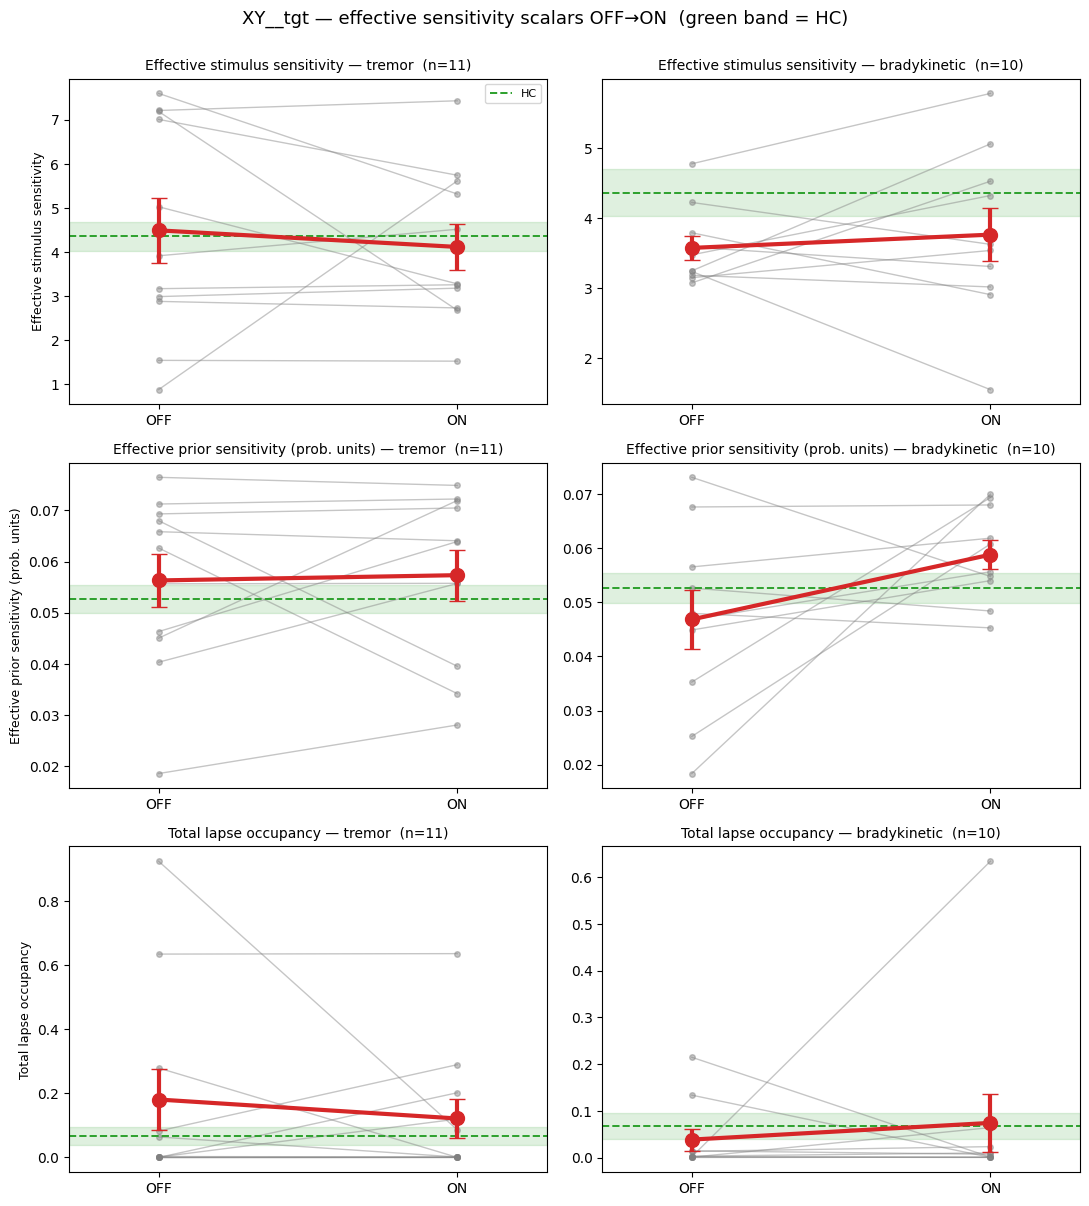

In [8]:
fig, axes = plt.subplots(3, 2, figsize=(11, 12), squeeze=False)
for mi, metric in enumerate(metrics):
    hc = df_m[df_m["subtype"] == "HC"][metric]; hc_m, hc_s = hc.mean(), hc.sem()
    for ax, sub in zip(axes[mi], ["tremor", "bradykinetic"]):
        pv = (pd_m.pivot_table(index="subject_id", columns="medication", values=metric, observed=True)
              .dropna(subset=["off", "on"]))
        sub_subj = pd_m[pd_m["subtype"] == sub]["subject_id"].unique()
        d = pv.loc[pv.index.isin(sub_subj)]
        for _, r in d.iterrows():
            ax.plot([0, 1], [r["off"], r["on"]], "-o", color="gray", alpha=0.45, lw=1, ms=4)
        ax.errorbar([0, 1], [d["off"].mean(), d["on"].mean()], yerr=[d["off"].sem(), d["on"].sem()],
                    color="tab:red", lw=3, marker="o", ms=10, capsize=6, zorder=5)
        ax.axhspan(hc_m - hc_s, hc_m + hc_s, color="tab:green", alpha=0.15)
        ax.axhline(hc_m, color="tab:green", ls="--", lw=1.4, label="HC")
        ax.set_xticks([0, 1]); ax.set_xticklabels(["OFF", "ON"]); ax.set_xlim(-0.3, 1.3)
        ax.set_title(f"{labels[metric]} — {sub}  (n={len(d)})", fontsize=10)
    axes[mi, 0].set_ylabel(labels[metric], fontsize=9)
axes[0, 0].legend(fontsize=8)
fig.suptitle(f"{CONFIG} — effective sensitivity scalars OFF→ON  (green band = HC)", fontsize=13, y=1.001)
plt.tight_layout(); plt.show()

## 6. Scalar vs clinical severity (PD OFF)

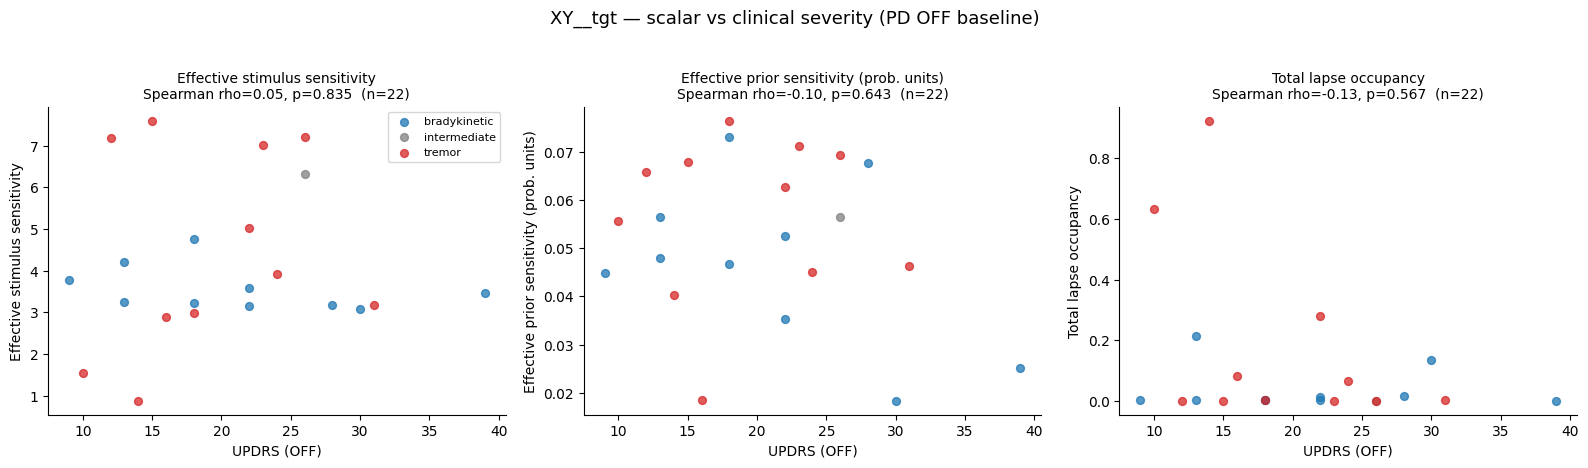

In [9]:
cmap = {"tremor": "tab:red", "bradykinetic": "tab:blue", "intermediate": "gray"}
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, metric in zip(axes, metrics):
    d = off_pd[[metric, "UPDRS", "subtype"]].dropna()
    for sub, dd in d.groupby("subtype", observed=True):
        ax.scatter(dd["UPDRS"], dd[metric], s=32, alpha=0.75, color=cmap.get(sub, "gray"), label=sub)
    if len(d) >= 5:
        rho, p = spearmanr(d["UPDRS"], d[metric])
        ax.set_title(f"{labels[metric]}\nSpearman rho={rho:.2f}, p={p:.3f}  (n={len(d)})", fontsize=10)
    ax.set_xlabel("UPDRS (OFF)"); ax.set_ylabel(labels[metric])
    ax.spines[["top", "right"]].set_visible(False)
axes[0].legend(fontsize=8)
fig.suptitle(f"{CONFIG} — scalar vs clinical severity (PD OFF baseline)", fontsize=13, y=1.03)
plt.tight_layout(); plt.show()

## 7. Read-out

Three comparable scalars replace the per-state comparisons, cutting the multiple-comparisons
burden to 3 metrics × a few contrasts. **Effective prior sensitivity** is the medication-relevant
DV (its OFF→ON Wilcoxon within Tremor / Brady); **effective stimulus sensitivity** and **lapse
occupancy** are controls — a medication effect that shows up on prior sensitivity but not on
stimulus sensitivity / lapse is specific to prior integration rather than a global
engagement/sensitivity shift. Because weights are on the shared basis, all three are directly
comparable HC vs PD and across subtype, and the UPDRS Spearman ties the latent-state scalar to
clinical severity. This is the clean per-subject summary of the weight × occupancy information;
6.10 (DDM cross-validation) and 6.11 (transition dynamics) are the mechanistic follow-ups.